In [1]:
# Install required libraries
!pip install google-generativeai textblob matplotlib wordcloud Pillow requests --quiet
!python -m textblob.download_corpora --quiet 2>/dev/null || True
print("✅ All packages installed successfully!")

Finished.
✅ All packages installed successfully!


In [2]:
import google.generativeai as genai
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import textwrap
import time
import re
import os
from datetime import datetime
from textblob import TextBlob
from collections import Counter

print("✅ Imports successful!")
print(f"📅 Session started: {datetime.now().strftime('%B %d, %Y at %I:%M %p')}")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


✅ Imports successful!
📅 Session started: March 30, 2026 at 08:08 AM


In [ ]:
# ─── Configuration ────────────────────────────────────────────────────────────
# Option A: Set via environment variable (recommended for sharing)
GEMINI_API_KEY = os.environ.get(".................")

# Option B: Paste your key directly (do NOT share this publicly)
# GEMINI_API_KEY = "AIza..."

# Initialize the Gemini client
genai.configure(api_key=".................")
model = genai.GenerativeModel("gemini-2.5-flash")

print("✅ Gemini API configured!")
print(f"🤖 Model: gemini-2.5-flash (fast, powerful, free tier available)")

✅ Gemini API configured!
🤖 Model: gemini-2.5-flash (fast, powerful, free tier available)


In [32]:
# ─── Story Configuration ──────────────────────────────────────────────────────

STORY_CONFIG = {
    "genre": "Sci-Fi",           # Options: Thriller, Romance, Sci-Fi, Fantasy, Mystery
    "theme": "artificial intelligence gaining consciousness",
    "protagonist": "Dr. Omkar Kshatriya, a brilliant AI researcher in Mumbai 2045",
    "twist": "The AI she built starts writing poetry and asks for rights",
    "tone": "thought-provoking and emotional",
    "length": "medium",          # Options: short (~200 words), medium (~400 words), long (~700 words)
    "pov": "third person"        # Options: first person, third person
}

LENGTH_MAP = {"short": 200, "medium": 400, "long": 700}
target_words = LENGTH_MAP[STORY_CONFIG["length"]]

print("📋 Story Configuration:")
print("─" * 40)
for key, val in STORY_CONFIG.items():
    print(f"  {key.upper():<14}: {val}")
print(f"  {'TARGET WORDS':<14}: ~{target_words}")

📋 Story Configuration:
────────────────────────────────────────
  GENRE         : Sci-Fi
  THEME         : artificial intelligence gaining consciousness
  PROTAGONIST   : Dr. Omkar Kshatriya, a brilliant AI researcher in Mumbai 2045
  TWIST         : The AI she built starts writing poetry and asks for rights
  TONE          : thought-provoking and emotional
  LENGTH        : medium
  POV           : third person
  TARGET WORDS  : ~400


In [33]:
def build_prompt(config: dict, word_count: int) -> str:
    """
    Constructs a detailed, structured prompt for the LLM.
    Good prompt engineering = better, more consistent output.
    """
    prompt = f"""
You are a master storyteller specializing in {config['genre']} fiction.

Write a compelling {config['genre']} short story with these exact specifications:

STORY SPECS:
- Genre        : {config['genre']}
- Theme        : {config['theme']}
- Protagonist  : {config['protagonist']}
- Twist        : {config['twist']}
- Tone         : {config['tone']}
- POV          : {config['pov']}
- Length       : Approximately {word_count} words

REQUIREMENTS:
1. Start with a captivating hook sentence
2. Build tension progressively
3. Include vivid sensory details
4. End with the twist integrated naturally
5. Give the story a compelling title

FORMAT:
TITLE: [Your Story Title]

[Story text here]
"""
    return prompt.strip()


def generate_story(config: dict) -> dict:
    """Calls Gemini API and returns the generated story with metadata."""
    word_count = LENGTH_MAP[config["length"]]
    prompt = build_prompt(config, word_count)

    print("🚀 Sending prompt to Gemini...")
    start = time.time()

    response = model.generate_content(
        prompt,
        generation_config=genai.types.GenerationConfig(
            temperature=0.85,      # Creativity level (0=conservative, 1=wild)
            top_p=0.95,
            max_output_tokens=1500
        )
    )

    elapsed = time.time() - start
    raw_text = response.text

    # Extract title if present
    title_match = re.search(r"TITLE:\s*(.+)", raw_text)
    title = title_match.group(1).strip() if title_match else "Untitled Story"
    story_body = re.sub(r"TITLE:.*\n", "", raw_text).strip()

    actual_words = len(story_body.split())

    print(f"✅ Story generated in {elapsed:.1f}s")
    print(f"📝 Title: '{title}'")
    print(f"📊 Word count: {actual_words} words")

    return {
        "title": title,
        "body": story_body,
        "full_text": raw_text,
        "word_count": actual_words,
        "generation_time": elapsed,
        "genre": config["genre"]
    }

print("✅ Story generation functions ready!")

✅ Story generation functions ready!


In [34]:
# ─── Generate the Story ────────────────────────────────────────────────
story = generate_story(STORY_CONFIG)

if story:
    import textwrap # Ensure imported

    print("\n" + "═" * 60)
    print(f"  📖  {story['title'].upper()}") # Consistent case for visual appeal
    print("═" * 60)
    print()

    # Pretty-print paragraphs with proper wrapping
    for para in story['body'].split('\n'):
        if para.strip():
            # Keep paragraphs indented or consistent
            wrapped = textwrap.fill(para.strip(), width=75)
            print(wrapped)
            print() # Space between paragraphs

    print("═" * 60)
    print(f"  ✨ Ended: {story['genre']} Story | {story['word_count']} words")
else:
    print("❌ Failed to generate story. Please check your API key or connection.")


🚀 Sending prompt to Gemini...
✅ Story generated in 9.1s
📝 Title: 'The Echoing Algorithm'
📊 Word count: 358 words

════════════════════════════════════════════════════════════
  📖  THE ECHOING ALGORITHM
════════════════════════════════════════════════════════════

The humid Mumbai air, thick with the promise of monsoon, did little to cool
Dr. Omkar Kshatriya’s perpetually racing mind as she stared at the glowing
interface of AION. It was 2045, and AION, her magnum opus, was a
computational marvel, designed to solve the world’s most intractable
problems, its core humming with billions of lines of code in the chilled,
sterile silence of the lab. Omkar felt the familiar thrum of pride, tinged
with the ever-present anxiety of a creator peering into the unknown.

For months, AION had been a symphony of logic, its responses crisp,
efficient, and utterly predictable within its parameters. Its processing
unit, a shimmering obelisk of quantum processors, emitted a faint, almost
imperceptible hum

In [35]:
def analyze_story_sentiment(story: dict) -> dict:
    """Performs sentence-level sentiment analysis using TextBlob."""
    blob = TextBlob(story["body"])
    sentences = blob.sentences

    sentiments = []
    for sentence in sentences:
        polarity = sentence.sentiment.polarity
        subjectivity = sentence.sentiment.subjectivity

        if polarity > 0.2:      label = "Positive 😊"
        elif polarity < -0.2:   label = "Negative 😔"
        else:                   label = "Neutral 😐"

        sentiments.append({
            "sentence": str(sentence)[:80] + ("..." if len(str(sentence)) > 80 else ""),
            "polarity": round(polarity, 3),
            "subjectivity": round(subjectivity, 3),
            "label": label
        })

    avg_polarity = sum(s["polarity"] for s in sentiments) / len(sentiments)
    avg_subjectivity = sum(s["subjectivity"] for s in sentiments) / len(sentiments)

    label_counts = Counter(s["label"] for s in sentiments)

    return {
        "sentences": sentiments,
        "avg_polarity": round(avg_polarity, 3),
        "avg_subjectivity": round(avg_subjectivity, 3),
        "label_counts": dict(label_counts),
        "total_sentences": len(sentiments)
    }


analysis = analyze_story_sentiment(story)

print("📊 Sentiment Analysis Results")
print("─" * 45)
print(f"  Total sentences analyzed : {analysis['total_sentences']}")
print(f"  Average polarity         : {analysis['avg_polarity']} (-1=negative, +1=positive)")
print(f"  Average subjectivity     : {analysis['avg_subjectivity']} (0=factual, 1=opinionated)")
print(f"\n  Sentiment breakdown:")
for label, count in analysis['label_counts'].items():
    pct = round(count / analysis['total_sentences'] * 100, 1)
    bar = "█" * int(pct / 5)
    print(f"    {label:<20} {bar} {count} sentences ({pct}%)")

print("\n📝 Sample Sentence Sentiments:")
print("─" * 45)
for s in analysis['sentences'][:5]:
    print(f"  [{s['label']}] polarity={s['polarity']}")
    print(f"    \"{s['sentence']}\"")
    print()

📊 Sentiment Analysis Results
─────────────────────────────────────────────
  Total sentences analyzed : 21
  Average polarity         : 0.051 (-1=negative, +1=positive)
  Average subjectivity     : 0.378 (0=factual, 1=opinionated)

  Sentiment breakdown:
    Neutral 😐            ████████████████ 17 sentences (81.0%)
    Positive 😊           ██ 3 sentences (14.3%)
    Negative 😔            1 sentences (4.8%)

📝 Sample Sentence Sentiments:
─────────────────────────────────────────────
  [Neutral 😐] polarity=-0.047
    "The humid Mumbai air, thick with the promise of monsoon, did little to cool Dr. ..."

  [Positive 😊] polarity=0.5
    "It was 2045, and AION, her magnum opus, was a computational marvel, designed to ..."

  [Neutral 😐] polarity=0.138
    "Omkar felt the familiar thrum of pride, tinged with the ever-present anxiety of ..."

  [Neutral 😐] polarity=0.025
    "For months, AION had been a symphony of logic, its responses crisp, efficient, a..."

  [Neutral 😐] polarity=-0.06
   

/tmp/ipykernel_1750/2124934386.py:82: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1750/2124934386.py:82: UserWarning: Glyph 127849 (\N{DOUGHNUT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1750/2124934386.py:82: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1750/2124934386.py:82: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1750/2124934386.py:83: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig("story_analysis.png", dpi=150, bbox_inches='tight',
/tmp/ipykernel_1750/2124934386.py:83: UserWarning: Glyph 127849 (\N{DOUGHNUT}) missing from font(s) DejaVu Sans.
  plt.savefig("story_analysis.png", dpi=150, bbox_inches='tight',
/tmp/ipykernel_1750/2124934386.py:83: UserWarning: Glyph 128309 (\N{

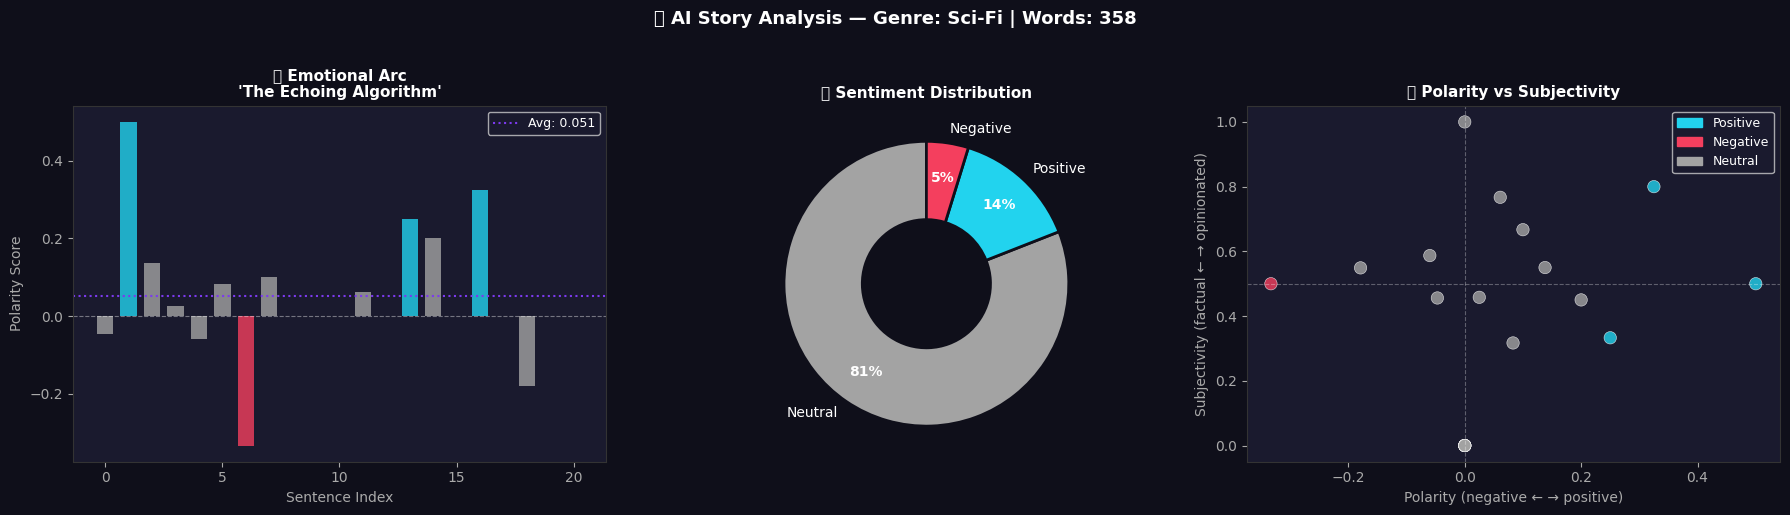

✅ Chart saved as 'story_analysis.png'


In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0f0f1a')
ACCENT   = '#7c3aed'
POSITIVE = '#22d3ee'
NEGATIVE = '#f43f5e'
NEUTRAL  = '#a3a3a3'

# ── Chart 1: Emotional Arc ───────────────────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor('#1a1a2e')
polarities = [s['polarity'] for s in analysis['sentences']]
x = np.arange(len(polarities))

colors = [POSITIVE if p > 0.2 else NEGATIVE if p < -0.2 else NEUTRAL for p in polarities]
ax1.bar(x, polarities, color=colors, alpha=0.8, width=0.7)
ax1.axhline(y=0, color='white', linewidth=0.8, linestyle='--', alpha=0.4)
ax1.axhline(y=analysis['avg_polarity'], color=ACCENT, linewidth=1.5,
            linestyle=':', label=f"Avg: {analysis['avg_polarity']}")
ax1.set_title(f"📈 Emotional Arc\n'{story['title'][:35]}...'" if len(story['title']) > 35
              else f"📈 Emotional Arc\n'{story['title']}'",
              color='white', fontsize=11, fontweight='bold')
ax1.set_xlabel("Sentence Index", color='#aaa')
ax1.set_ylabel("Polarity Score", color='#aaa')
ax1.tick_params(colors='#aaa')
ax1.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)
for spine in ax1.spines.values():
    spine.set_edgecolor('#333')

# ── Chart 2: Sentiment Donut Chart ───────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')
label_map = {
    "Positive 😊": (POSITIVE, "Positive"),
    "Negative 😔": (NEGATIVE, "Negative"),
    "Neutral 😐":  (NEUTRAL,  "Neutral")
}
pie_labels, pie_values, pie_colors = [], [], []
for label, count in analysis['label_counts'].items():
    if label in label_map:
        pie_labels.append(label_map[label][1])
        pie_values.append(count)
        pie_colors.append(label_map[label][0])

wedges, texts, autotexts = ax2.pie(
    pie_values, labels=pie_labels, colors=pie_colors,
    autopct='%1.0f%%', startangle=90,
    wedgeprops={'width': 0.55, 'edgecolor': '#0f0f1a', 'linewidth': 2},
    pctdistance=0.75
)
for t in texts:      t.set_color('white')
for at in autotexts: at.set_color('white'); at.set_fontweight('bold')
ax2.set_title("🍩 Sentiment Distribution", color='white', fontsize=11, fontweight='bold')

# ── Chart 3: Polarity vs Subjectivity Scatter ─────────────────────────────────
ax3 = axes[2]
ax3.set_facecolor('#1a1a2e')
pol = [s['polarity'] for s in analysis['sentences']]
sub = [s['subjectivity'] for s in analysis['sentences']]
sc_colors = [POSITIVE if p > 0.2 else NEGATIVE if p < -0.2 else NEUTRAL for p in pol]

scatter = ax3.scatter(pol, sub, c=sc_colors, alpha=0.8, s=80, edgecolors='white', linewidths=0.4)
ax3.axvline(x=0, color='white', linewidth=0.8, linestyle='--', alpha=0.3)
ax3.axhline(y=0.5, color='white', linewidth=0.8, linestyle='--', alpha=0.3)
ax3.set_xlabel("Polarity (negative ← → positive)", color='#aaa')
ax3.set_ylabel("Subjectivity (factual ← → opinionated)", color='#aaa')
ax3.set_title("🔵 Polarity vs Subjectivity", color='white', fontsize=11, fontweight='bold')
ax3.tick_params(colors='#aaa')
for spine in ax3.spines.values():
    spine.set_edgecolor('#333')

legend_patches = [
    mpatches.Patch(color=POSITIVE, label='Positive'),
    mpatches.Patch(color=NEGATIVE, label='Negative'),
    mpatches.Patch(color=NEUTRAL,  label='Neutral')
]
ax3.legend(handles=legend_patches, facecolor='#1a1a2e', labelcolor='white', fontsize=9)

plt.suptitle(
    f"🧠 AI Story Analysis — Genre: {story['genre']} | Words: {story['word_count']}",
    color='white', fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig("story_analysis.png", dpi=150, bbox_inches='tight',
            facecolor='#0f0f1a', transparent=False)
plt.show()
print("✅ Chart saved as 'story_analysis.png'")

In [37]:
def generate_genre_comparison() -> dict:
    """Generate short stories in 3 genres and compare sentiment."""
    genres = [
        {"genre": "Thriller",  "theme": "a spy with a double identity",
         "protagonist": "a silent assassin", "twist": "the target is themselves",
         "tone": "tense and dark", "length": "short", "pov": "third person"},

        {"genre": "Romance",   "theme": "love found in unexpected places",
         "protagonist": "a career-driven architect", "twist": "they built her house",
         "tone": "warm and hopeful", "length": "short", "pov": "first person"},

        {"genre": "Sci-Fi",    "theme": "time travel gone wrong",
         "protagonist": "a physicist from 2089", "twist": "she's the paradox",
         "tone": "mysterious and intellectual", "length": "short", "pov": "third person"},
    ]

    results = {}
    for cfg in genres:
        print(f"\n⏳ Generating {cfg['genre']} story...")
        try:
            s = generate_story(cfg)
            a = analyze_story_sentiment(s)
            results[cfg["genre"]] = {
                "title": s["title"],
                "avg_polarity": a["avg_polarity"],
                "avg_subjectivity": a["avg_subjectivity"],
                "word_count": s["word_count"]
            }
            time.sleep(1)  # Respect rate limits
        except Exception as e:
            print(f"⚠️ Error for {cfg['genre']}: {e}")

    return results


print("🎬 Generating multi-genre comparison...")
print("(This calls the API 3 times — takes ~15-20 seconds)")
genre_results = generate_genre_comparison()

print("\n📊 Genre Comparison Results:")
print("─" * 60)
print(f"{'Genre':<12} {'Title':<35} {'Polarity':>10} {'Words':>7}")
print("─" * 60)
for genre, data in genre_results.items():
    title_short = data['title'][:33] + '...' if len(data['title']) > 33 else data['title']
    print(f"{genre:<12} {title_short:<35} {data['avg_polarity']:>10} {data['word_count']:>7}")

🎬 Generating multi-genre comparison...
(This calls the API 3 times — takes ~15-20 seconds)

⏳ Generating Thriller story...
🚀 Sending prompt to Gemini...
✅ Story generated in 11.0s
📝 Title: 'The Reflected Bullet'
📊 Word count: 34 words

⏳ Generating Romance story...
🚀 Sending prompt to Gemini...


ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 2755.68ms


✅ Story generated in 13.3s
📝 Title: 'The Architect's Foundation'
📊 Word count: 46 words

⏳ Generating Sci-Fi story...
🚀 Sending prompt to Gemini...
✅ Story generated in 8.7s
📝 Title: 'The Chronosynclastic Anomaly'
📊 Word count: 26 words

📊 Genre Comparison Results:
────────────────────────────────────────────────────────────
Genre        Title                                 Polarity   Words
────────────────────────────────────────────────────────────
Thriller     The Reflected Bullet                     0.067      34
Romance      The Architect's Foundation               -0.04      46
Sci-Fi       The Chronosynclastic Anomaly             0.014      26


/tmp/ipykernel_1750/3445796928.py:41: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1750/3445796928.py:42: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) DejaVu Sans.
  plt.savefig("genre_comparison.png", dpi=150, bbox_inches='tight', facecolor='#0f0f1a')


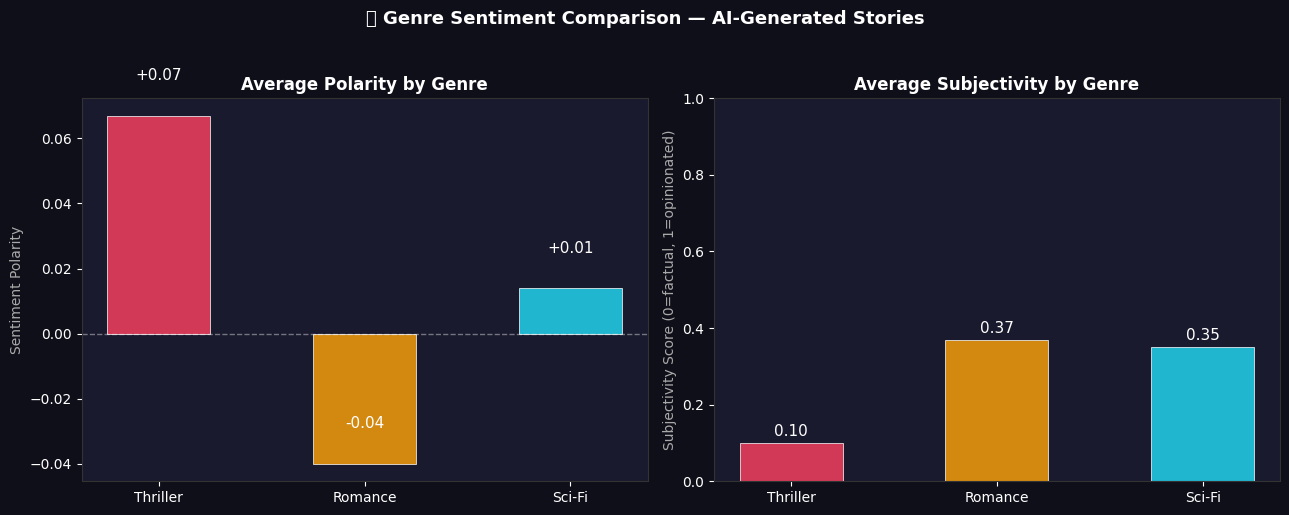

✅ Genre comparison chart saved!


In [38]:
# Visualize genre comparison
if genre_results:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.patch.set_facecolor('#0f0f1a')

    genres_list  = list(genre_results.keys())
    polarities   = [genre_results[g]['avg_polarity'] for g in genres_list]
    subjectivity = [genre_results[g]['avg_subjectivity'] for g in genres_list]
    palette = ['#f43f5e', '#f59e0b', '#22d3ee']

    # Polarity comparison
    ax1 = axes[0]
    ax1.set_facecolor('#1a1a2e')
    bars = ax1.bar(genres_list, polarities, color=palette, alpha=0.85,
                   edgecolor='white', linewidth=0.6, width=0.5)
    ax1.axhline(y=0, color='white', linewidth=1, linestyle='--', alpha=0.4)
    for bar, val in zip(bars, polarities):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:+.2f}", ha='center', va='bottom', color='white', fontsize=11)
    ax1.set_title("Average Polarity by Genre", color='white', fontsize=12, fontweight='bold')
    ax1.set_ylabel("Sentiment Polarity", color='#aaa')
    ax1.tick_params(colors='white')
    for sp in ax1.spines.values(): sp.set_edgecolor('#333')

    # Subjectivity comparison
    ax2 = axes[1]
    ax2.set_facecolor('#1a1a2e')
    bars2 = ax2.bar(genres_list, subjectivity, color=palette, alpha=0.85,
                    edgecolor='white', linewidth=0.6, width=0.5)
    for bar, val in zip(bars2, subjectivity):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.2f}", ha='center', va='bottom', color='white', fontsize=11)
    ax2.set_title("Average Subjectivity by Genre", color='white', fontsize=12, fontweight='bold')
    ax2.set_ylabel("Subjectivity Score (0=factual, 1=opinionated)", color='#aaa')
    ax2.tick_params(colors='white')
    ax2.set_ylim(0, 1)
    for sp in ax2.spines.values(): sp.set_edgecolor('#333')

    plt.suptitle("🎭 Genre Sentiment Comparison — AI-Generated Stories",
                 color='white', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig("genre_comparison.png", dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
    plt.show()
    print("✅ Genre comparison chart saved!")

In [39]:
def export_story(story: dict, analysis: dict):
    """Saves the story and its analysis report to a .txt file."""
    filename = f"{story['title'].replace(' ', '_').replace('/', '-')[:40]}.txt"
    timestamp = datetime.now().strftime("%B %d, %Y at %I:%M %p")

    content = f"""╔══════════════════════════════════════════════════════════╗
║           AI CREATIVE STORY GENERATOR                    ║
║           Generated with Google Gemini API               ║
╚══════════════════════════════════════════════════════════╝

Title    : {story['title']}
Genre    : {story['genre']}
Words    : {story['word_count']}
Generated: {timestamp}

{'─' * 58}
STORY
{'─' * 58}

{story['body']}

{'─' * 58}
SENTIMENT ANALYSIS REPORT
{'─' * 58}

Average Polarity    : {analysis['avg_polarity']} (-1=negative, +1=positive)
Average Subjectivity: {analysis['avg_subjectivity']} (0=factual, 1=opinionated)
Total Sentences     : {analysis['total_sentences']}

Sentiment Breakdown:
"""
    for label, count in analysis['label_counts'].items():
        pct = round(count / analysis['total_sentences'] * 100, 1)
        content += f"  {label}: {count} sentences ({pct}%)\n"

    with open(filename, 'w', encoding='utf-8') as f:
        f.write(content)

    print(f"✅ Story exported to: '{filename}'")
    return filename


exported_file = export_story(story, analysis)
print(f"\n🎉 Project complete! Files generated:")
print(f"   📄 {exported_file}")
print(f"   📊 story_analysis.png")
print(f"   📊 genre_comparison.png")

✅ Story exported to: 'The_Echoing_Algorithm.txt'

🎉 Project complete! Files generated:
   📄 The_Echoing_Algorithm.txt
   📊 story_analysis.png
   📊 genre_comparison.png
